# Trend plots
Trend plots help visualize long-term movement in a time series: upward, downward, seasonal, smoothed, etc.

Below you get:

✔ Basic trend plot

✔ Smoothed trend (Rolling Mean)

✔ Polynomial trend

✔ LOESS/LOWESS trend

✔ Trend + confidence band

✔ Line + scatter trend

✔ Detrended plot

✔ Trend decomposition plot (trend only)

✔ Trend with highlights (min/max)

✔ Trend for multiple time series

✔ Beautiful Seaborn styles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Basic Trend Plot

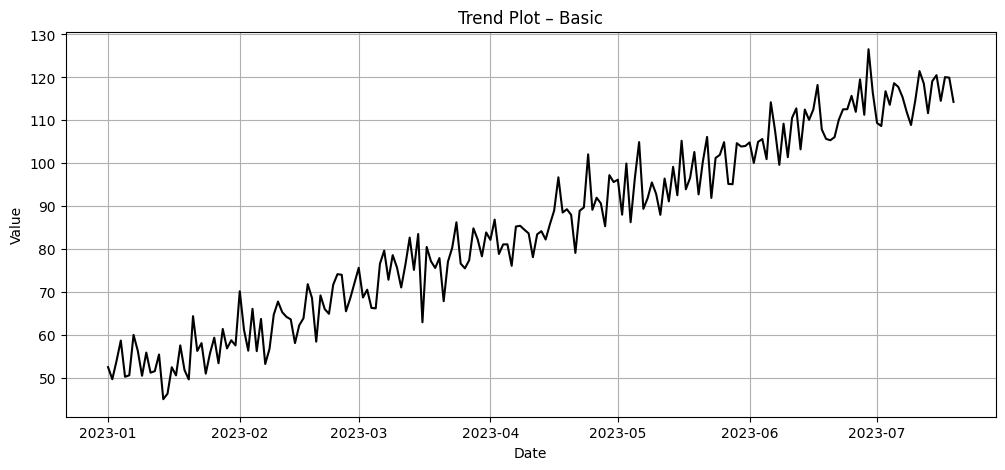

In [2]:
# Sample time-series
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=200)
values = np.linspace(50, 120, 200) + np.random.normal(0, 5, 200)
df = pd.DataFrame({"date": dates, "value": values})

# Basic trend plot
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], color='black')
plt.title("Trend Plot – Basic")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()


## Trend Plot with Rolling Mean (Smoothed Trend)

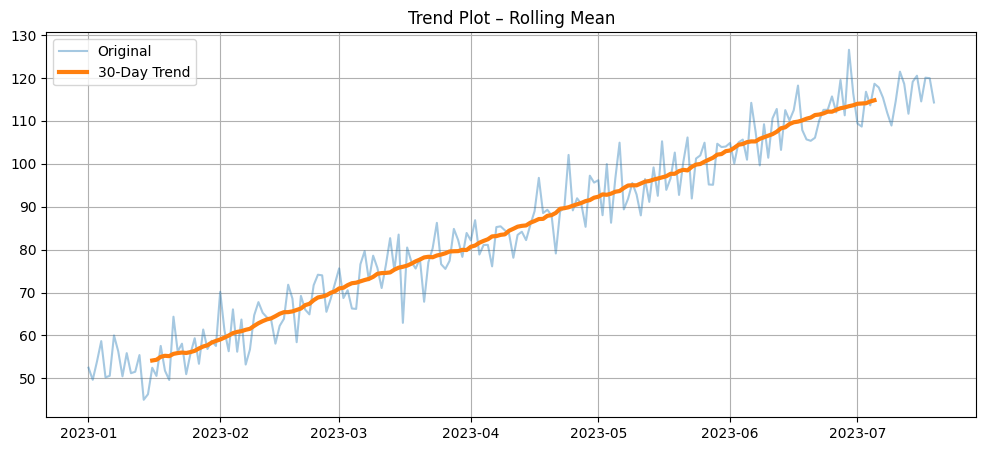

In [3]:
df['rolling_30'] = df['value'].rolling(30, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], alpha=0.4, label="Original")
plt.plot(df['date'], df['rolling_30'], linewidth=3, label="30-Day Trend")
plt.title("Trend Plot – Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()


## Trend Plot with LOWESS (LOESS) Smoothing

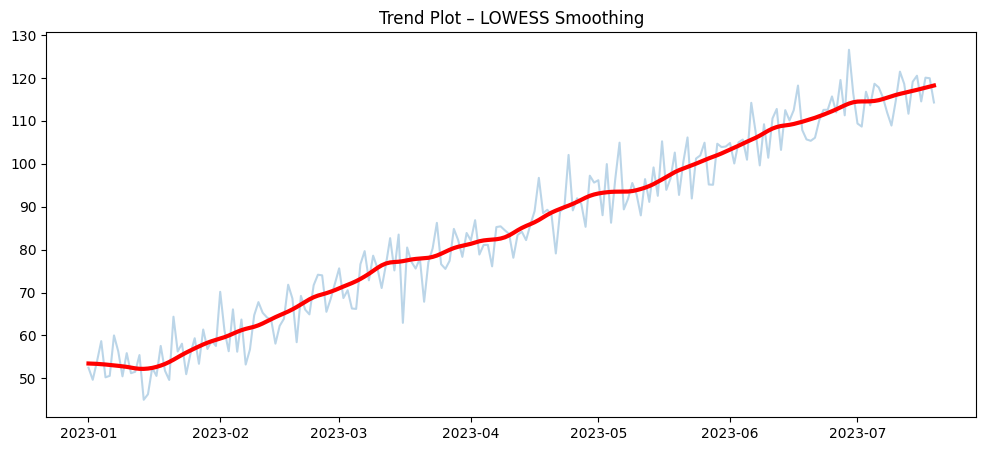

In [4]:
import statsmodels.api as sm

lowess = sm.nonparametric.lowess(df['value'], df['date'], frac=0.1)
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], alpha=0.3)
plt.plot(df['date'], lowess[:,1], color='red', linewidth=3)
plt.title("Trend Plot – LOWESS Smoothing")
plt.show()


## Polynomial Trend (Degree = 2 or 3)

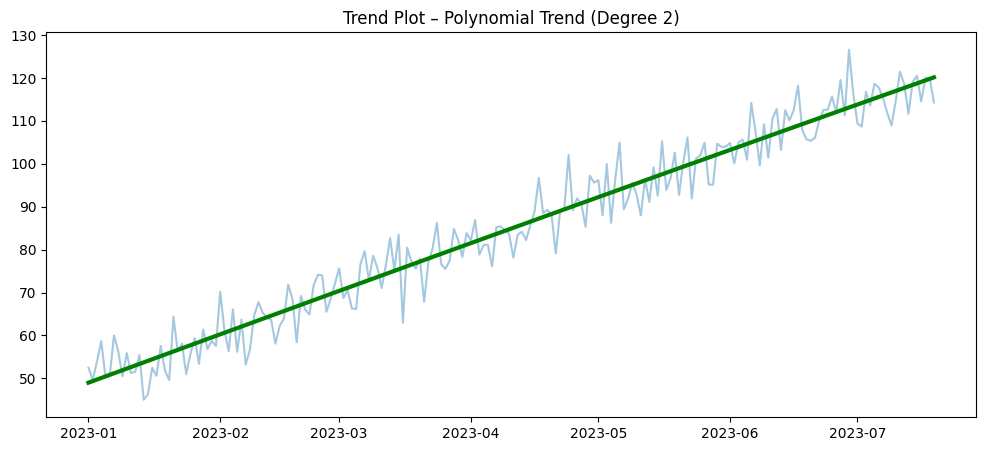

In [5]:
x = np.arange(len(df))
coeffs = np.polyfit(x, df['value'], deg=2)
poly_trend = np.polyval(coeffs, x)

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], alpha=0.4)
plt.plot(df['date'], poly_trend, color='green', linewidth=3)
plt.title("Trend Plot – Polynomial Trend (Degree 2)")
plt.show()


## Trend with Confidence Band

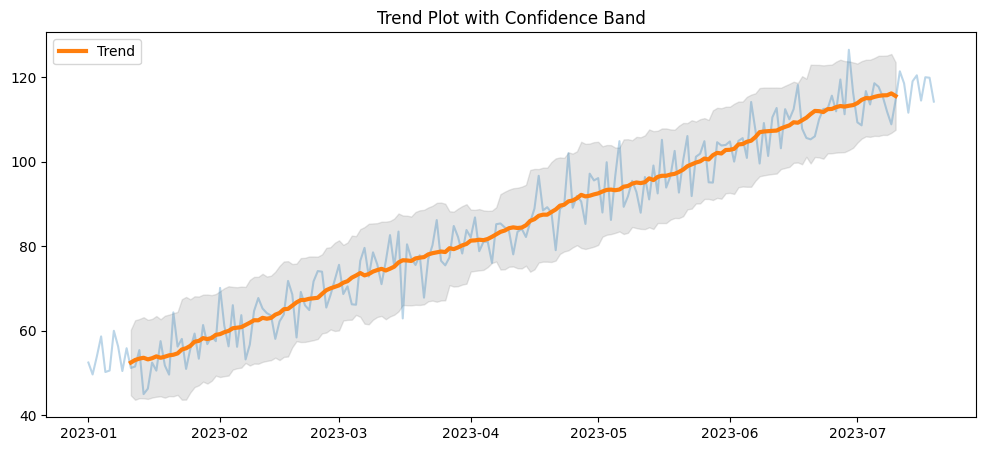

In [6]:
rolling = df['value'].rolling(20, center=True)
mean = rolling.mean()
std = rolling.std()

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], alpha=0.3)
plt.plot(df['date'], mean, linewidth=3, label="Trend")

# confidence band
plt.fill_between(df['date'], mean-2*std, mean+2*std, alpha=0.2, color='gray')
plt.title("Trend Plot with Confidence Band")
plt.legend()
plt.show()


## Trend + Scatter (Seaborn style)

c:\Users\NIL\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\NIL\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


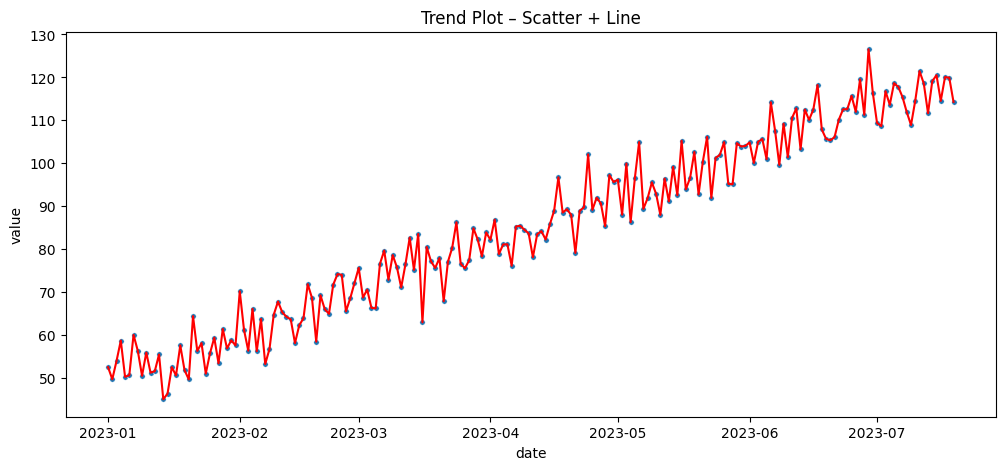

In [7]:
import seaborn as sns

plt.figure(figsize=(12,5))
sns.scatterplot(x=df['date'], y=df['value'], s=15)
sns.lineplot(x=df['date'], y=df['value'], color='red')
plt.title("Trend Plot – Scatter + Line")
plt.show()


## Detrended Plot (Trend Removed)

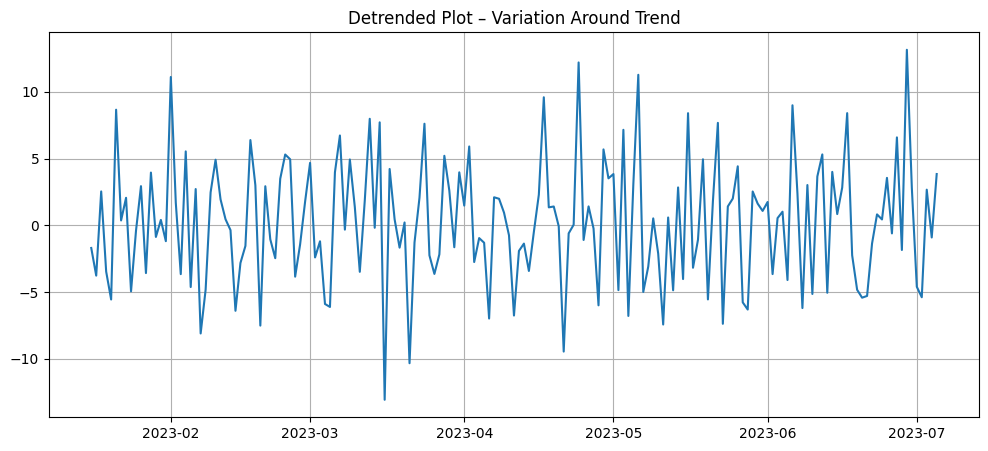

In [8]:
trend = df['value'].rolling(30, center=True).mean()
detrended = df['value'] - trend

plt.figure(figsize=(12,5))
plt.plot(df['date'], detrended)
plt.title("Detrended Plot – Variation Around Trend")
plt.grid(True)
plt.show()


## Trend Extracted From Seasonal Decomposition

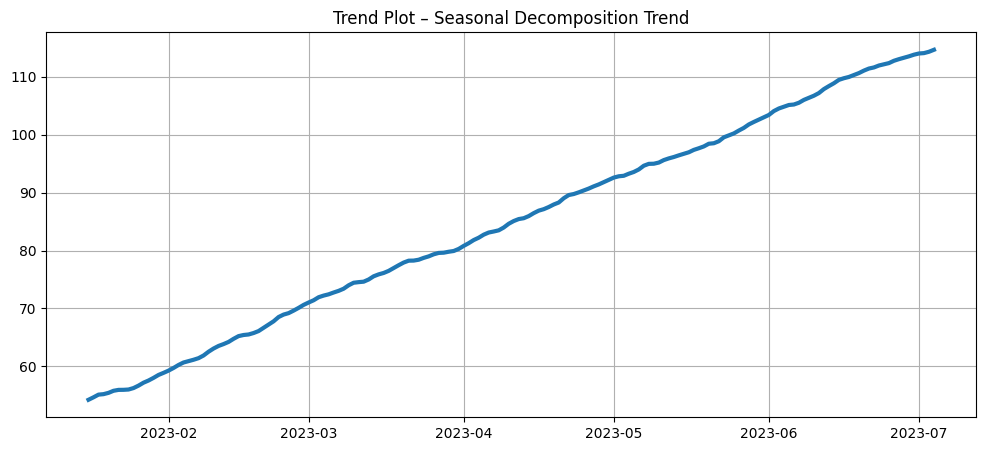

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['value'], model='additive', period=30)

plt.figure(figsize=(12,5))
plt.plot(df['date'], result.trend, linewidth=3)
plt.title("Trend Plot – Seasonal Decomposition Trend")
plt.grid(True)
plt.show()


## Trend with Highlights (min/max points)

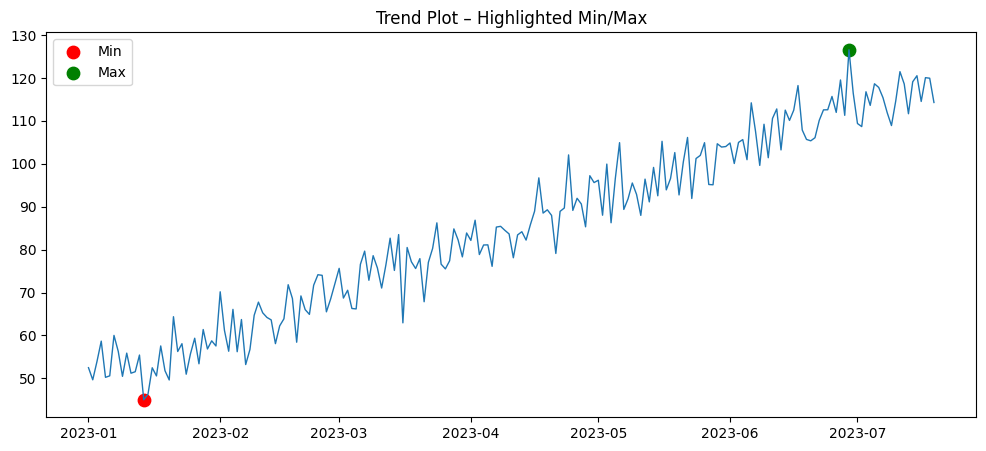

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], linewidth=1)

min_idx = df['value'].idxmin()
max_idx = df['value'].idxmax()

plt.scatter(df['date'][min_idx], df['value'][min_idx], color='red', s=80, label='Min')
plt.scatter(df['date'][max_idx], df['value'][max_idx], color='green', s=80, label='Max')

plt.title("Trend Plot – Highlighted Min/Max")
plt.legend()
plt.show()


## Trend Comparison of Multiple Series

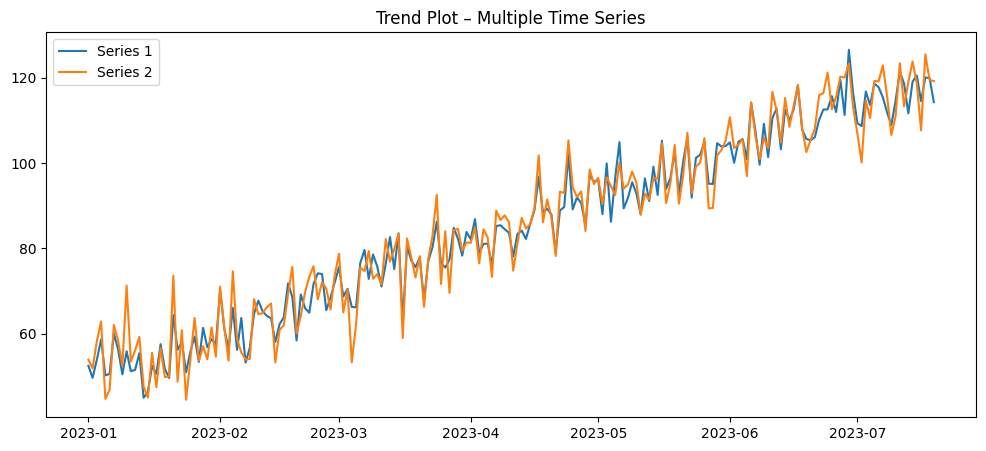

In [11]:
df['value2'] = df['value'] + np.random.normal(0, 4, len(df))

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'], label='Series 1')
plt.plot(df['date'], df['value2'], label='Series 2')
plt.title("Trend Plot – Multiple Time Series")
plt.legend()
plt.show()


## Rolling Trend Slope (Rate of Trend Change)

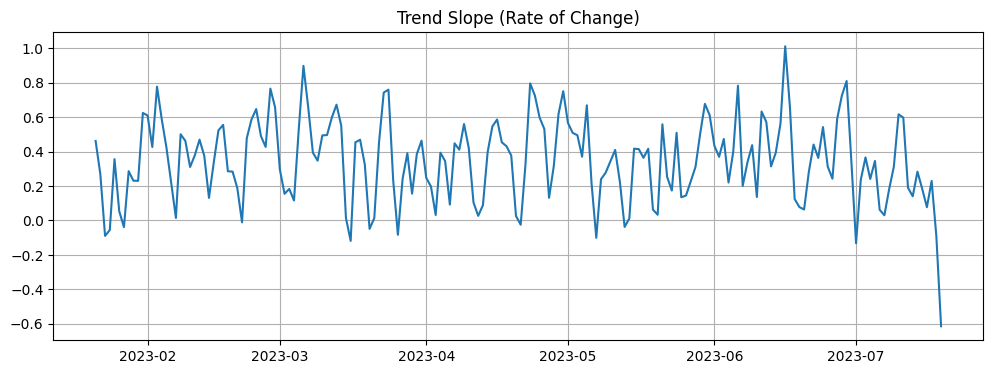

In [12]:
window = 20
slopes = np.gradient(df['value'].rolling(window).mean())

plt.figure(figsize=(12,4))
plt.plot(df['date'], slopes)
plt.title("Trend Slope (Rate of Change)")
plt.grid(True)
plt.show()
